### **5. Analizar antes de programar**

*   <p align="justify"> <strong>¿Qué variables creen que serán más útiles para clasificar un lugar? </strong>enchufes, soporte_para_trabajar, internet_wifi y silencio, ya que definen las condiciones básicas para que un robot pueda operar.<p>

---


*   <p align="justify"> <strong>¿Qué variables podrían aportar poca información?</strong> banos_cerca o cafeteria_cerca podrían no afectar directamente la capacidad del robot para trabajar durante 30 minutos, siendo más irrelevantes que las condiciones físicas del entorno.<p>

---


*   <p align="justify"> <strong>¿Existen variables con escalas numéricas muy diferentes?</strong>  No, todas las variables de características (X) son binarias (0 o 1). No hay diferencias de escala, por lo que no es estrictamente necesario normalizar o estandarizar los datos antes de calcular las distancias.<p>

---


*   <p align="justify"> <strong>¿Está balanceada la variable Apto / No apto?</strong>  Sí. El dataset cuenta con 65 registros en total, divididos en 34 casos "Aptos" (Target=1) y 31 casos "No aptos" (Target=0).<p>

---


*   <p align="justify"> <strong>¿Qué significa que dos lugares sean “cercanos” en este problema?</strong> Significa que comparten condiciones ambientales e infraestructurales muy similares. Al tener variables binarias, la "cercanía" representa la cantidad de características exactas que dos lugares tienen en común.<p>

In [ ]:
# =====================================================================
# CELDA 1 - Librerías y carga del Dataset v1.0 desde Kaggle
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

ruta = kagglehub.dataset_download('schiaffino89/lugares-aptos-para-trabajar')
df = pd.read_csv(os.path.join(ruta, 'Dataset v1.0.csv'))

print("Registros y columnas:", df.shape)
df.head()

100%|██████████| 1.31k/1.31k [00:00<00:00, 2.40MB/s]

Extracting files...
Registros y columnas: (65, 13)


,Lugar,silencio,sombra,aire_acondicionado,soporte_para_trabajar,asientos,asientos_comodos,enchufes,flujo_personas,banos_cerca,cafeteria_cerca,internet_wifi,Target
0,Plaza Cosmos,0,0,0,1,1,1,0,0,1,0,1,0
1,Laboratorio 4 de posgrado,1,1,1,1,1,1,1,1,1,0,1,1
2,Domo de enfermeria,0,1,1,0,1,0,0,0,1,1,1,0
3,Mesas de trabajo social,0,1,1,1,1,1,1,0,1,0,1,1
4,Medios didacticos,1,1,1,0,1,1,0,1,1,0,1,0


In [ ]:
# =====================================================================
# CELDA 2 - Revisión: nulos, duplicados y valores de cada variable
# =====================================================================
variables = [c for c in df.columns if c not in ('Lugar', 'Target')]

print("Valores nulos:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("Registros con las mismas características que otro:", df[variables].duplicated().sum())
print("\nValores distintos por variable:")
for c in variables:
    print(f"  {c:<22} {sorted(df[c].unique().tolist())}")

Valores nulos: 0
Filas duplicadas: 0
Registros con las mismas características que otro: 23

Valores distintos por variable:
  silencio               [0, 1]
  sombra                 [0, 1]
  aire_acondicionado     [0, 1]
  soporte_para_trabajar  [0, 1]
  asientos               [0, 1]
  asientos_comodos       [0, 1]
  enchufes               [0, 1]
  flujo_personas         [0, 1]
  banos_cerca            [0, 1]
  cafeteria_cerca        [0, 1]
  internet_wifi          [0, 1]


Target
0    31
1    34
Name: count, dtype: int64
Target
0    47.7
1    52.3
Name: proportion, dtype: float64


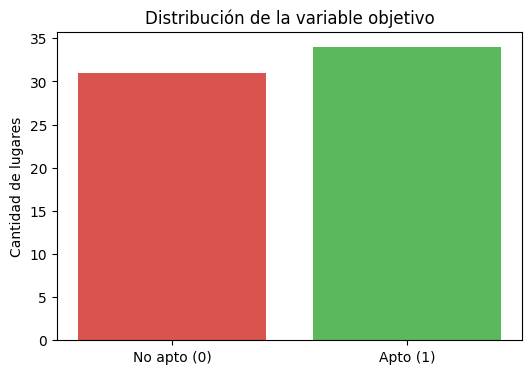

In [ ]:
# =====================================================================
# CELDA 3 - Balance de la variable objetivo (pregunta 4)
# =====================================================================

conteo = df['Target'].value_counts().sort_index() # Cuenta cuántos lugares hay de cada clase y los ordena: primero 0 (No apto), luego 1 (Apto)
print(conteo)
print((df['Target'].value_counts(normalize=True).sort_index() * 100).round(1)) # Mismo conteo pero en porcentaje

plt.figure(figsize=(6, 4))
plt.bar(['No apto (0)', 'Apto (1)'], conteo.values, color=['#d9534f', '#5cb85c'])
plt.title('Distribución de la variable objetivo')
plt.ylabel('Cantidad de lugares')
plt.show()

,variable,% apto si vale 0,% apto si vale 1,correlacion
3,soporte_para_trabajar,0.0,91.9,0.91
5,asientos_comodos,11.5,79.5,0.67
6,enchufes,25.0,86.2,0.61
2,aire_acondicionado,28.1,75.8,0.48
4,asientos,0.0,63.0,0.47
1,sombra,8.3,62.3,0.42
7,flujo_personas,73.3,34.3,-0.39
0,silencio,37.8,71.4,0.33
8,banos_cerca,26.3,63.0,0.33
10,internet_wifi,0.0,54.8,0.23


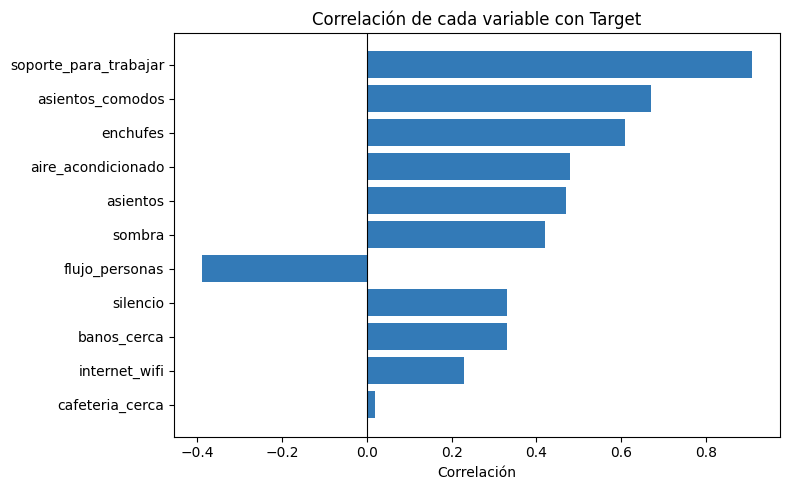

In [ ]:
# =====================================================================
# CELDA 4 - Correlación de cada variable con Target (preguntas 1 y 2)
# =====================================================================
resumen = []
for c in variables:
    resumen.append({
        'variable': c,
        '% apto si vale 0': round(df.loc[df[c] == 0, 'Target'].mean() * 100, 1), # filtra los lugares donde la variable vale 0 y calcula el promedio
        '% apto si vale 1': round(df.loc[df[c] == 1, 'Target'].mean() * 100, 1),
        'correlacion': round(df[c].corr(df['Target']), 2), # La correlación resume la relación en un solo número entre −1 y 1
    })

# Convierte la lista en tabla y la ordena de la variable más fuerte a la más débil,
# usando el valor absoluto para que las correlaciones negativas no queden al final.
resumen = pd.DataFrame(resumen).sort_values('correlacion', key=abs, ascending=False)
display(resumen)

plt.figure(figsize=(8, 5))
plt.barh(resumen['variable'], resumen['correlacion'], color='#337ab7')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.title('Correlación de cada variable con Target')
plt.xlabel('Correlación')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELDA 5 - Separar características (X) y objetivo (y)
# =====================================================================

X = df[variables].values # convierte la tabla de Pandas en un arreglo de NumPy
y = df['Target'].values # Toma solo la columna Target
nombres = df['Lugar'].values # Guarda los nombres de los lugares en un arreglo aparte

print("X:", X.shape, " y:", y.shape) # X son dos numeros porque es una tabla de dos dimensiones, mientras que y es una lista de una dimension

X: (65, 11)  y: (65,)


In [ ]:
def distancia_euclidiana(a, b):
    # Resta variable por variable, eleva al cuadrado, suma y saca raíz.
    return np.sqrt(np.sum((a - b) ** 2))


def knn_predecir(X_train, y_train, x, k):
    # 1. Calcular la distancia entre x y cada registro de entrenamiento
    distancias = np.array([distancia_euclidiana(x, fila) for fila in X_train])
    # 2. Ordenar las distancias
    orden = np.argsort(distancias, kind='stable')
    # 3. Seleccionar los k vecinos más cercanos
    vecinos = orden[:k]
    # 4. Identificar sus clases y contar los votos
    clases, votos = np.unique(y_train[vecinos], return_counts=True)
    # 5. La predicción es la clase con más votos
    return clases[np.argmax(votos)]


def knn_predecir_varios(X_train, y_train, X_test, k):
    # Aplica knn_predecir a cada lugar de X_test y regresa todas las predicciones en un arreglo
    return np.array([knn_predecir(X_train, y_train, x, k) for x in X_test])

### **Parte 3**
--------------------------------------------------------------------------------

In [ ]:
# =====================================================================
# CELDA 7 - División entrenamiento / prueba (80/20, la misma para todos los experimentos)
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# random_state=42 hace que la división sea siempre la misma
# y stratify=y conserva la proporción de Apto / No apto en ambos conjuntos.
X_train, X_test, y_train, y_test, lugar_train, lugar_test = train_test_split(
    X, y, nombres, test_size=0.2, random_state=42, stratify=y
)

# len cuenta los registros y np.bincount cuenta cuántos 0 y cuántos 1 hay en cada conjunto
print("Entrenamiento:", len(X_train), "registros ->", np.bincount(y_train), "(No apto, Apto)")
print("Prueba:       ", len(X_test), "registros ->", np.bincount(y_test), "(No apto, Apto)")

Entrenamiento: 52 registros -> [25 27] (No apto, Apto)
Prueba:        13 registros -> [6 7] (No apto, Apto)


,k,Exactitud entrenamiento,Exactitud prueba
0,1,1.000,0.923
1,3,0.923,0.923
2,5,0.962,0.923
3,7,0.942,0.923
4,9,0.923,0.923


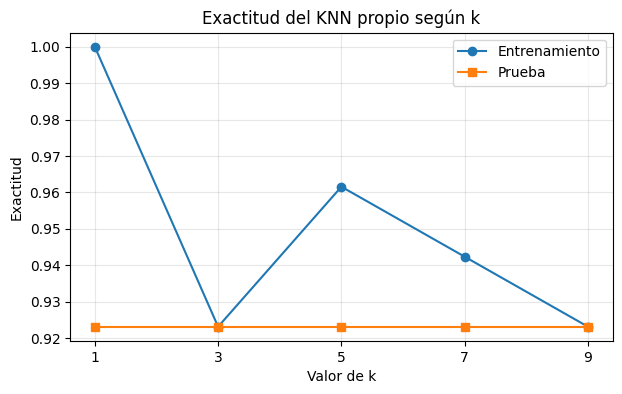

In [ ]:
# =====================================================================
# CELDA 8 - KNN propio con k = 1, 3, 5, 7 y 9
# =====================================================================
valores_k = [1, 3, 5, 7, 9]
resultados_k = [] # Lista vacía para guardar una fila por cada k

for k in valores_k:
    pred_train = knn_predecir_varios(X_train, y_train, X_train, k)  # Predice los mismos lugares de entrenamiento
    pred_test = knn_predecir_varios(X_train, y_train, X_test, k) # Predice los lugares de prueba
    resultados_k.append({
        'k': k,
        'Exactitud entrenamiento': accuracy_score(y_train, pred_train),
        'Exactitud prueba': accuracy_score(y_test, pred_test),
    })

tabla_k = pd.DataFrame(resultados_k)
display(tabla_k.round(3))

plt.figure(figsize=(7, 4))
plt.plot(tabla_k['k'], tabla_k['Exactitud entrenamiento'], marker='o', label='Entrenamiento')
plt.plot(tabla_k['k'], tabla_k['Exactitud prueba'], marker='s', label='Prueba')
plt.xticks(valores_k)
plt.xlabel('Valor de k')
plt.ylabel('Exactitud')
plt.title('Exactitud del KNN propio según k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **• ¿qué efecto produjo cambiar k?**
En prueba ninguno: con todos los k la exactitud es 0.923 y el error es el mismo lugar. En entrenamiento sí cambia, porque k = 1 memoriza y saca 1.000.
### **• ¿el valor más grande siempre fue mejor?**
No. k = 9 empata con k = 1 en prueba, y con k de 17 o más la exactitud baja.
### **• ¿qué valor elegirían y por qué?**
k = 5: empata en prueba, no depende de un solo vecino y, al ser impar, no hay empates en la votación.

In [ ]:
# =====================================================================
# CELDA 9 - Comparación con KNN de scikit-learn
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier

comparacion = []  # Lista vacía para guardar una fila por cada k
for k in valores_k:
    pred_propio = knn_predecir_varios(X_train, y_train, X_test, k) # Predicciones de nuestro KNN sobre los lugares de prueba
    # KNN de sklearn: se crea con k vecinos, se entrena (fit) y predice la prueba (predict)
    pred_sklearn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).predict(X_test)
    comparacion.append({
        'k': k,
        'Exactitud KNN propio': accuracy_score(y_test, pred_propio),
        'Exactitud KNN sklearn': accuracy_score(y_test, pred_sklearn),
        # Porcentaje de lugares en los que ambos predicen lo mismo
        'Coincidencia': np.mean(pred_propio == pred_sklearn),
    })

display(pd.DataFrame(comparacion).round(3))

,k,Exactitud KNN propio,Exactitud KNN sklearn,Coincidencia
0,1,0.923,0.923,1.0
1,3,0.923,0.923,1.0
2,5,0.923,0.923,1.0
3,7,0.923,0.923,1.0
4,9,0.923,0.923,1.0


### **¿Esperan que el modelo asignado tenga un desempeño mejor, similar o peor que KNN? ¿Por qué?**

Esperamos que el SVM tenga un desempeño similar a KNN, o tal vez un poco mejor, porque puede darle más importancia a las variables que sí sirven y KNN las trata a todas igual.

In [ ]:
# =====================================================================
# CELDA 10 - Modelo asignado: Support Vector Machine (SVM)
# =====================================================================
from sklearn.svm import SVC

# Kernel lineal: busca una frontera recta entre Apto y No apto.
modelo_svm = SVC(kernel='linear') # Crea el modelo
modelo_svm.fit(X_train, y_train) # Lo entrena con el mismo 80% que usó KNN
pred_svm = modelo_svm.predict(X_test) # Predice el mismo 20% de prueba

# Misma métrica que KNN para que la comparación sea justa
print(f"Exactitud SVM en prueba: {accuracy_score(y_test, pred_svm):.3f}")
print("\nMatriz de confusión (filas = real, columnas = predicción):")
print(confusion_matrix(y_test, pred_svm)) # Cuenta aciertos y errores por clase

# Peso que el SVM le dio a cada variable para decidir
pesos = pd.Series(modelo_svm.coef_[0], index=variables).sort_values(key=abs, ascending=False)
display(pesos.round(2).to_frame('Peso en el SVM'))

Exactitud SVM en prueba: 1.000

Matriz de confusión (filas = real, columnas = predicción):
[[6 0]
 [0 7]]


,Peso en el SVM
soporte_para_trabajar,2.00
sombra,1.00
enchufes,0.01
internet_wifi,0.00
aire_acondicionado,0.00
cafeteria_cerca,0.00
banos_cerca,-0.00
asientos_comodos,-0.00
silencio,0.00
asientos,0.00


,Modelo,Exactitud,Lugares mal clasificados
0,KNN propio (k=5),0.923,Mesas al lado del starvocho
1,KNN sklearn (k=5),0.923,Mesas al lado del starvocho
2,SVM (lineal),1.000,Ninguno


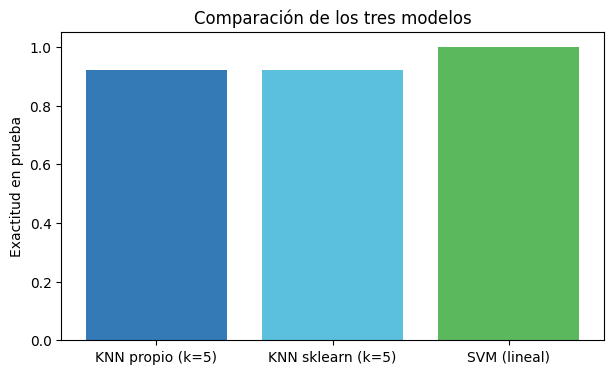

In [ ]:
# =====================================================================
# CELDA 11 - Comparación final de los 3 modelos y análisis de errores
# =====================================================================
k_elegido = 5

# Predicciones finales de ambos KNN con el k elegido
pred_knn_propio = knn_predecir_varios(X_train, y_train, X_test, k_elegido)
pred_knn_sklearn = KNeighborsClassifier(n_neighbors=k_elegido).fit(X_train, y_train).predict(X_test)

# Diccionario nombre del modelo -> sus predicciones
modelos = {
    f'KNN propio (k={k_elegido})': pred_knn_propio,
    f'KNN sklearn (k={k_elegido})': pred_knn_sklearn,
    'SVM (lineal)': pred_svm,
}

tabla_final = pd.DataFrame({
    'Modelo': list(modelos.keys()),
    'Exactitud': [accuracy_score(y_test, p) for p in modelos.values()],
    'Lugares mal clasificados': [', '.join(lugar_test[p != y_test]) or 'Ninguno' for p in modelos.values()],
})
display(tabla_final.round(3))

plt.figure(figsize=(7, 4))
plt.bar(tabla_final['Modelo'], tabla_final['Exactitud'], color=['#337ab7', '#5bc0de', '#5cb85c'])
plt.ylim(0, 1.05)
plt.ylabel('Exactitud en prueba')
plt.title('Comparación de los tres modelos')
plt.show()

### **Reflexión final**

### **1. ¿En qué sentido KNN “aprendió” a partir de los datos?**
 En realidad no aprende reglas, solo guarda los lugares de entrenamiento. Cuando llega uno nuevo, busca los más parecidos y le asigna la clase que más se repite entre ellos.
### **2. ¿Qué diferencia existe entre este modelo y las reglas manuales creadas en la primera actividad?**
Las reglas manuales las hicimos nosotros según lo que creíamos importante. KNN no tiene reglas: decide comparando con lugares reales, así que si cambian los datos cambian sus decisiones.
### **3. ¿Qué decisiones tuvieron mayor impacto en los resultados?**
El criterio de Apto / No apto que definimos como grupo, porque hizo que soporte_para_trabajar casi decidiera la clase por sí sola. También influyó cómo se dividieron los datos, porque con solo 13 lugares de prueba un lugar más o menos cambia bastante la exactitud.
### **4. ¿Cuál es actualmente la principal limitación del modelo?**
Que tenemos muy pocos datos. Con 65 lugares la prueba queda de 13, y cada error baja casi 8 puntos la exactitud, así que no podemos asegurar qué modelo es realmente mejor. Además KNN le da el mismo peso a todas las variables, aunque algunas casi no sirven.
### **5. Si pudieran mejorar una sola cosa, ¿mejorarían los datos, las variables o el algoritmo? ¿Por qué?**
Los datos. Los modelos ya aciertan casi todo, así que cambiar el algoritmo no ayudaría mucho.